In [1]:
import numpy as np
import matplotlib.pyplot as plt
print('Setup complete!')

Setup complete!


In [2]:
# The LIF equation (discrete time version):
#
# V[t+1] = V[t] + dt * ( -(V[t] - V_rest) / tau + I[t] / C )
#
# Where:
# V = membrane potential (voltage)
# V_rest = resting potential (what V returns to with no input)
# tau = membrane time constant (how fast voltage decays)
# I = input current
# C = membrane capacitance
# dt = time step size

In [3]:
# ============ Simulation Parameters ============
T = 1.0        # Total simulation time (seconds)
dt = 0.001     # Time step (1 ms)
time = np.arange(0, T, dt)   # Time array
I_input = np.zeros(len(time))
I_input[200:800] = 1000.0

# ============ Neuron Parameters ============
V_rest = -70.0     # Resting potential (mV)
V_thresh = -55.0   # Spike threshold (mV)
V_reset = -75.0    # Reset potential after spike (mV)
tau = 0.020        # Membrane time constant (20 ms)
C = 1.0            # Membrane capacitance (normalized)

print(f'Simulation: {T}s with {len(time)} time steps')
print(f'Threshold: {V_thresh} mV, Rest: {V_rest} mV')

Simulation: 1.0s with 1000 time steps
Threshold: -55.0 mV, Rest: -70.0 mV


- 1. Why is V_reset (-75 mV) lower than V_rest (-70 mV)? What biological phenomenon does this
represent? 	V_reset is lower than V_rest to model afterhyperpolarization, when potassium efflux makes the neuron briefly more negative after a spike, reducing immediate refiring probability.

- 2. The time constant tau is 20 ms. In plain English, what does this control?	The time constant tau controls how quickly membrane voltage changes, determining how fast the neuron responds to input and returns toward resting potential.


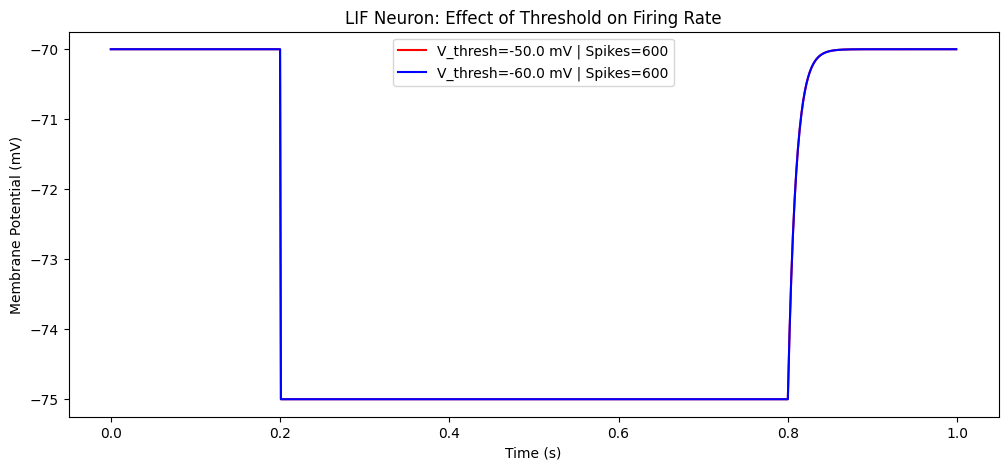

In [4]:
# EXPERIMENT 1
# ===== Simulation parameters =====
T = 1.0        # Total time (s)
dt = 0.001
time = np.arange(0, T, dt)
I_input = np.zeros(len(time))
I_input[200:800] = 1000.0  # Strong input pulse

# ===== Neuron parameters =====
V_rest = -70.0
V_reset = -75.0
tau = 0.010
C = 1.0

# ===== Thresholds to test =====
thresholds = [-50.0, -60.0]
colors = ['red', 'blue']

plt.figure(figsize=(12, 5))

for V_thresh, color in zip(thresholds, colors):
    V = np.full(len(time), V_rest)
    spike_times = []

    for t in range(len(time)-1):
        dV = (dt / tau) * (-(V[t] - V_rest) + I_input[t]/C)
        V[t+1] = V[t] + dV

        if V[t+1] >= V_thresh:
            spike_times.append(time[t+1])
            V[t+1] = V_reset

    # Plot membrane potential
    plt.plot(time, V, color=color, label=f'V_thresh={V_thresh} mV | Spikes={len(spike_times)}')

plt.title('LIF Neuron: Effect of Threshold on Firing Rate')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.show()

- Experiment 1: Threshold Sensitivity
Go back to your single LIF neuron (Part A). Change V_thresh from -55 to -50, then to -60. How
does the firing rate change? Plot both and compare.


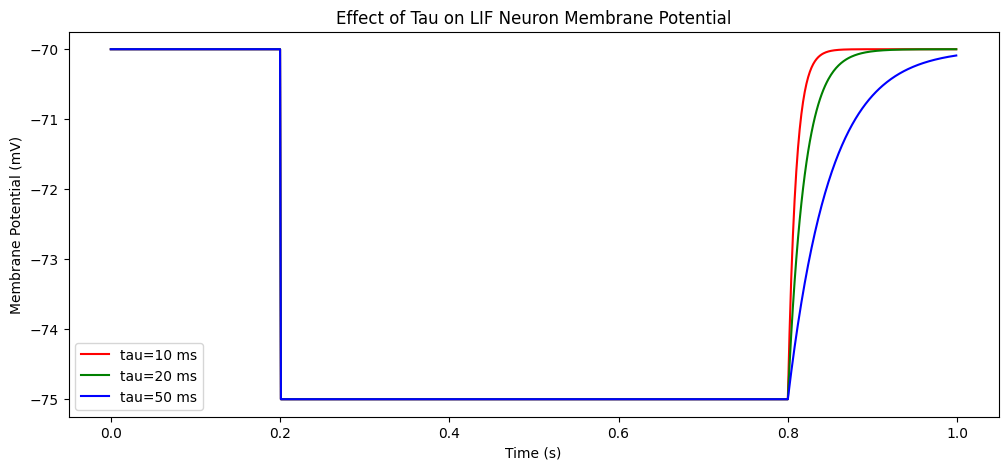

In [5]:
#EXPERIMENT 2
# ===== Simulation parameters =====
T = 1.0
dt = 0.001
time = np.arange(0, T, dt)
I_input = np.zeros(len(time))
I_input[200:800] = 1000.0  # Strong pulse

# ===== Neuron parameters =====
V_rest = -70.0
V_reset = -75.0
V_thresh = -55.0
C = 1.0

taus = [0.010, 0.020, 0.050]  # 10 ms, 20 ms, 50 ms
colors = ['red', 'green', 'blue']

plt.figure(figsize=(12,5))

for tau, color in zip(taus, colors):
    V = np.full(len(time), V_rest)

    for t in range(len(time)-1):
        dV = (dt / tau) * (-(V[t] - V_rest) + I_input[t]/C)
        V[t+1] = V[t] + dV
        if V[t+1] >= V_thresh:
            V[t+1] = V_reset

    plt.plot(time, V, color=color, label=f'tau={int(tau*1000)} ms')

plt.title('Effect of Tau on LIF Neuron Membrane Potential')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Potential (mV)')
plt.legend()
plt.show()

EX2: Change tau from 20 ms to 10 ms, then 50 ms. How does this affect the shape of the membrane potential curve between spikes?
- Reducing or increasing τ (tau) changes how quickly the membrane potential responds to input.
	•	τ = 10 ms (smaller) → The membrane charges and discharges faster. The voltage rises more steeply toward threshold and resets more sharply. Spikes occur sooner after input begins.
	•	τ = 50 ms (larger) → The membrane changes more slowly. The voltage rises gradually with a smoother, slower curve between spikes. It takes longer to reach threshold.

- Smaller τ = faster, steeper voltage changes.
- Larger τ = slower, smoother voltage changes.



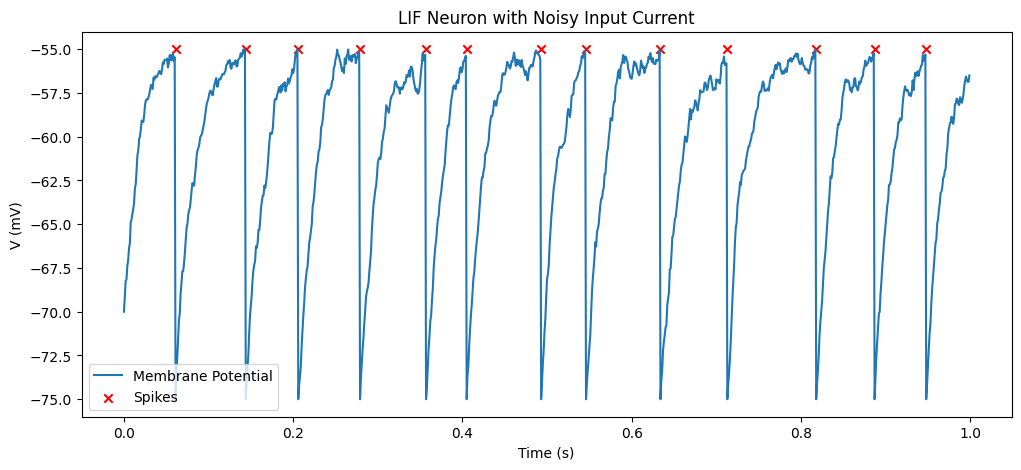

In [6]:
#EXPERIMENT 3
# ===== Simulation parameters =====
T = 1.0
dt = 0.001
time = np.arange(0, T, dt)

# Constant input with Gaussian noise
I_noisy = 15.0 + np.random.randn(len(time)) * 5.0  # mean 15, std 5

# ===== Neuron parameters =====
V_rest = -70.0
V_reset = -75.0
V_thresh = -55.0
tau = 0.020
C = 1.0

# ===== Simulation =====
V = np.full(len(time), V_rest)
spike_times = []

for t in range(len(time)-1):
    dV = (dt / tau) * (-(V[t] - V_rest) + I_noisy[t]/C)
    V[t+1] = V[t] + dV

    if V[t+1] >= V_thresh:
        spike_times.append(time[t+1])
        V[t+1] = V_reset

# ===== Plot =====
plt.figure(figsize=(12,5))
plt.plot(time, V, label='Membrane Potential')
plt.scatter(spike_times, [V_thresh]*len(spike_times), color='red', marker='x', label='Spikes')
plt.xlabel('Time (s)')
plt.ylabel('V (mV)')
plt.title('LIF Neuron with Noisy Input Current')
plt.legend()
plt.show()

- Noise makes spike timing irregular.
-	With constant input, spikes occur at nearly regular intervals.
-	Adding noise causes the membrane potential to fluctuate, so the neuron reaches threshold earlier or later, making inter-spike intervals variable.
- In short: noise introduces randomness, breaking the regularity of spike patterns.

In [7]:
# Make sure spikes list exists
spikes = []

# ===== Simulation Loop =====
for t in range(len(time) - 1):

    # Compute voltage change (LIF equation)
    dV = dt * (-(V[t] - V_rest) / tau + I_input[t] / C)

    # Update membrane potential
    V[t+1] = V[t] + dV

    # Check for spike
    if V[t+1] >= V_thresh:
        spikes.append(time[t+1])  # corrected name
        V[t+1] = V_reset

print(f'Neuron fired {len(spikes)} spikes')

Neuron fired 18 spikes


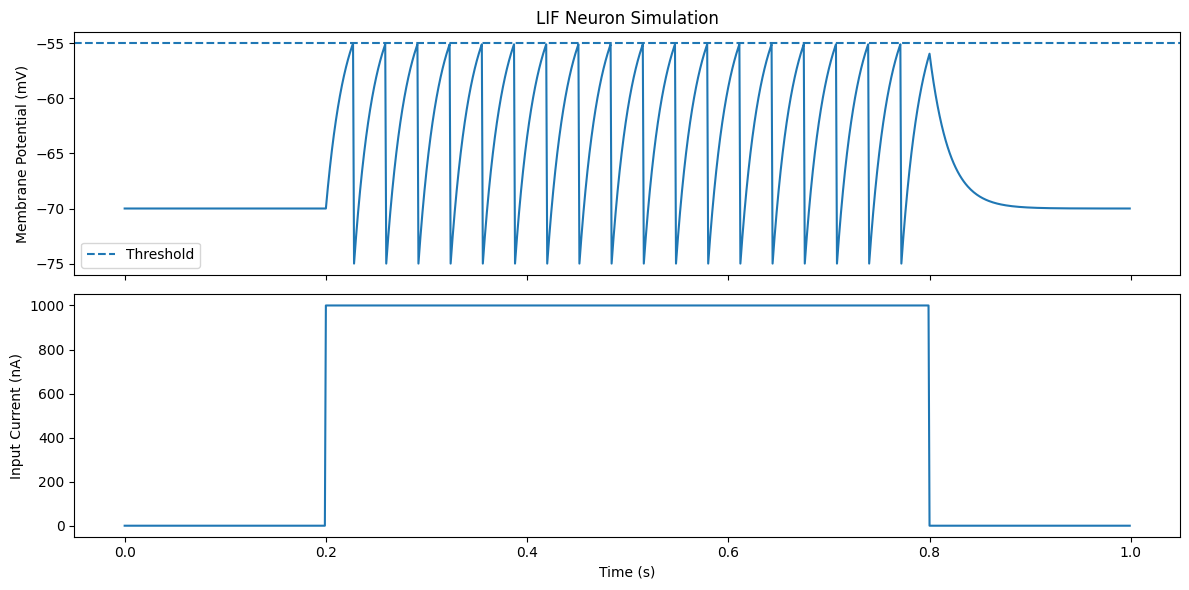

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# ===== Plot membrane potential =====
ax1.plot(time, V)
ax1.axhline(y=V_thresh, linestyle='--', label='Threshold')
ax1.set_ylabel('Membrane Potential (mV)')
ax1.set_title('LIF Neuron Simulation')
ax1.legend()

# ===== Plot input current =====
ax2.plot(time, I_input)
ax2.set_ylabel('Input Current (nA)')
ax2.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

- 1. Look at your membrane potential plot. What happens to V between spikes — does it go straight up, or does it curve? Why?
Between spikes, V curves upward rather than going straight up.
This happens because the membrane follows exponential charging toward a steady-state voltage due to the leak term in the LIF equation.

- 2. What happens to V after the current turns off at t=800ms? Why does it behave this way?
After the current turns off at 800 ms, V decays smoothly back to −70 mV. With no input current, only the leak remains, so voltage exponentially relaxes back to the resting potential.

In [9]:
def rate_encode(values, num_steps=100):
    """
    Convert an array of values (0 to 1) into spike trains.
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for t in range(num_steps):
        # Generate random numbers and compare to firing probabilities
        spikes[t] = (np.random.rand(num_neurons) < values).astype(float)

    return spikes

In [10]:
# Test with 5 values of increasing intensity
test_values = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_spikes = rate_encode(test_values, num_steps=200)

# Count spikes per neuron
for i, v in enumerate(test_values):
    count = np.sum(test_spikes[:, i])
    print(f'Value {v:.1f} -> {count:.0f} spikes in 200 steps')

Value 0.1 -> 20 spikes in 200 steps
Value 0.3 -> 59 spikes in 200 steps
Value 0.5 -> 96 spikes in 200 steps
Value 0.7 -> 143 spikes in 200 steps
Value 0.9 -> 176 spikes in 200 steps


In [11]:
def temporal_encode(values, num_steps=100, threshold=0.05):
    """
    Convert values (0 to 1) into spike trains using time-to-first-spike.
    Higher values spike earlier.
    """
    num_neurons = len(values)
    spikes = np.zeros((num_steps, num_neurons))

    for i, v in enumerate(values):
        if v >= threshold:
            # Map value (0→1) to spike time (late→early)
            spike_time = int((1 - v) * (num_steps - 1))
            spikes[spike_time, i] = 1.0

    return spikes

- 1. In rate coding, what information is lost about the original signal? What is preserved?	In rate coding, precise spike timing is lost. Only average firing rate is preserved, so temporal patterns are discarded while overall signal intensity remains represented.

- 2. In temporal coding, why might it be faster for a downstream neuron to make a decision compared to rate coding?	In temporal coding, information is carried by the first spikes timing, allowing downstream neurons to respond immediately, rather than waiting to estimate firing rate over time.

- 3. Can you think of a real-world example where timing matters more than frequency? 	Sound localization is a real-world example. The brain compares tiny timing differences between ears to determine direction, where timing matters more than spike frequency.

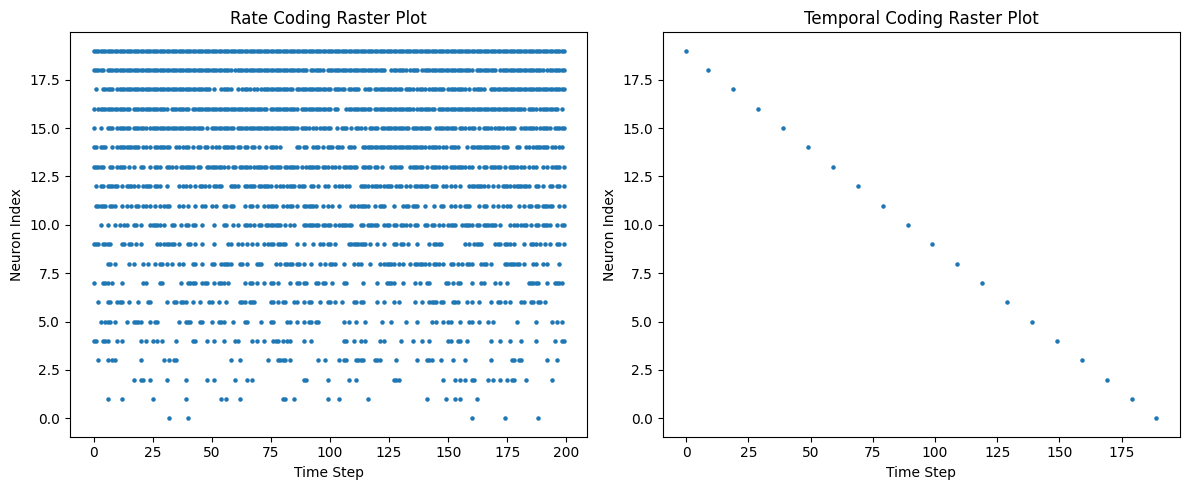

In [12]:
# Create a test signal: 20 values from 0.05 to 1.0
signal = np.linspace(0.05, 1.0, 20)

# Encode with both methods
rate_spikes = rate_encode(signal, num_steps=200)
temp_spikes = temporal_encode(signal, num_steps=200)

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------------------------
# Left: Rate Coding Raster
# ---------------------------
times_rate, neurons_rate = np.where(rate_spikes == 1)
axes[0].scatter(times_rate, neurons_rate, s=5)
axes[0].set_title("Rate Coding Raster Plot")
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Neuron Index")

# ---------------------------
# Right: Temporal Coding Raster
# ---------------------------
times_temp, neurons_temp = np.where(temp_spikes == 1)
axes[1].scatter(times_temp, neurons_temp, s=5)
axes[1].set_title("Temporal Coding Raster Plot")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Neuron Index")

plt.tight_layout()
plt.show()

In [13]:
# ===== Simulation constants =====
dt = 0.001
tau_m = 0.02
V_rest = -65
V_reset = -65
V_threshold = -50

# ===== Network parameters =====
N = 5
T_net = 0.5
time_net = np.arange(0, T_net, dt)
steps = len(time_net)

# ===== Weight matrix =====
weights = np.zeros((N, N))
weights[0, 2] = 12.0
weights[1, 3] = 12.0
weights[2, 4] = 10.0
weights[3, 4] = 10.0

# ===== External input =====
I_ext = np.zeros((steps, N))
I_ext[100:400, 0] = 18.0
I_ext[150:350, 1] = 18.0

# ===== Storage =====
V_net = np.full((steps, N), V_rest)
spike_log = [[] for _ in range(N)]

In [14]:
spiked = np.zeros(N)

for t in range(steps - 1):
    spiked[:] = 0

    for n in range(N):
        I_total = I_ext[t, n] + np.sum(weights[:, n] * spiked)

        dV = (dt / tau_m) * (-(V_net[t, n] - V_rest) + I_total)
        V_net[t+1, n] = V_net[t, n] + dV

        if V_net[t+1, n] >= V_threshold:
            spike_log[n].append(time_net[t+1])
            V_net[t+1, n] = V_reset
            spiked[n] = 1

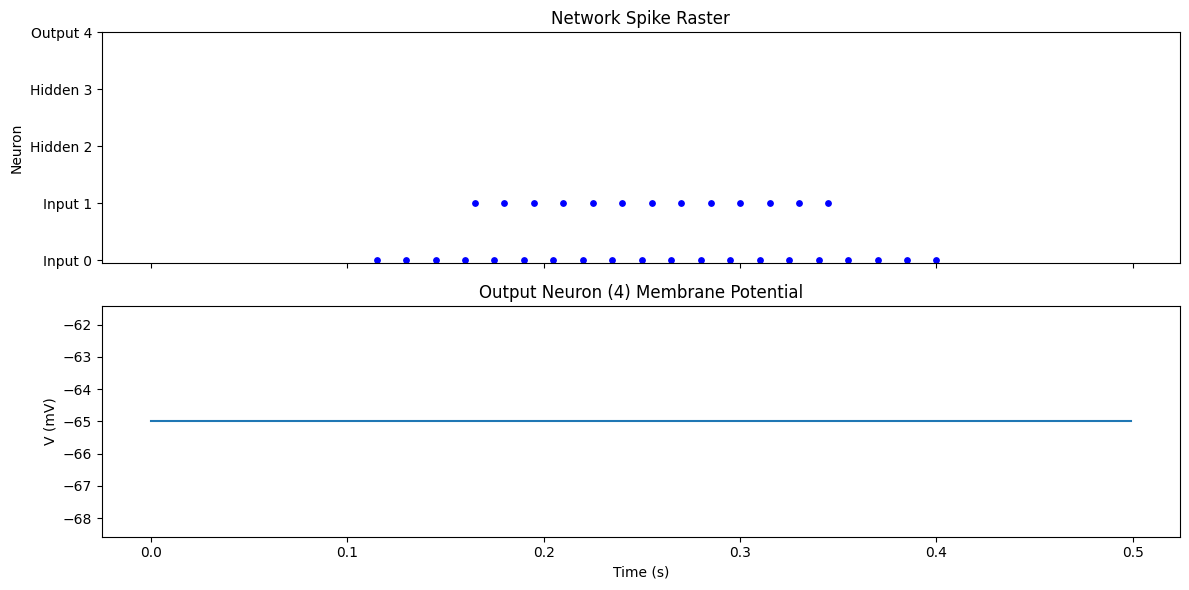

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# ===== TODO 12: Raster Plot =====
for n in range(N):
    if n in [0, 1]:
        color = 'blue'      # Input neurons
    elif n in [2, 3]:
        color = 'green'     # Hidden neurons
    else:
        color = 'red'       # Output neuron

    ax1.scatter(spike_log[n], [n]*len(spike_log[n]),
                color=color, s=15)

ax1.set_ylabel('Neuron')
ax1.set_title('Network Spike Raster')
ax1.set_yticks(range(N))
ax1.set_yticklabels(['Input 0', 'Input 1', 'Hidden 2', 'Hidden 3', 'Output 4'])

# ===== TODO 13: Output neuron membrane potential =====
ax2.plot(time_net, V_net[:, 4])
ax2.set_ylabel('V (mV)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Output Neuron (4) Membrane Potential')

plt.tight_layout()
plt.show()

- 1. Does the output neuron fire at the same rate as the input neurons? Why or why not? No, it does not. The output neuron usually fires at a different rate because it receives indirect, combined synaptic input from upstream neurons, so its firing depends on their timing and weight strength.

- 2. What role do the synaptic weights play? What would happen if you doubled them? Halved them? Synaptic weights control influence strength. Doubling them increases firing rate and sensitivity; halving them weakens input, possibly preventing spikes if the threshold is not reached.

- 3. In the brain, not all connections are excitatory. What might happen if you made weights[3, 4]
negative (inhibitory)? A negative weight adds inhibition. Neuron 3 would suppress neuron 4's activity, reducing, delaying, or even completely preventing the output neuron from firing.

- EXPERIMENT REFLECTIONS

Experiment 1: Changing Tau (τ)
	1.	Parameter changed: Membrane time constant τ = 10 ms, 20 ms, 50 ms
	2.	Expectation: Smaller τ means membrane potential should rise and decay faster. While a larger τ means membrane potential should rise and decay more slowly.
	3.	Results:
	• Plots show:
	•	τ = 10 ms → steep, fast voltage changes between spikes
	•	τ = 20 ms → moderate slope
	•	τ = 50 ms → slow, smooth voltage changes
	•	Spike timing slightly affected for extreme τ values.
	4.	Explanation:
	•	From LIF equation:
\frac{dV}{dt} = \frac{-(V-V_{rest}) + I}{\tau}
	•	Smaller τ → larger dV/dt, faster voltage change
	•	Larger τ → smaller dV/dt, slower voltage change

Experiment 2: Changing Spike Threshold (V_thresh)
	1.	Parameter changed:
	•	V_thresh = -50 mV, -55 mV, -60 mV
	2.	Expectation:
	•	Lower threshold → neuron should fire more easily (higher firing rate)
	•	Higher threshold → neuron should fire less often (lower firing rate)
	3.	Results:
	•	Plots show:
	•	V_thresh = -50 → more spikes
	•	V_thresh = -55 → medium spikes
	•	V_thresh = -60 → fewer spikes
	4.	Explanation:
	•	LIF spike occurs when V \ge V_{thresh}.
	•	Lower threshold reduces the voltage needed to spike, increasing firing rate; higher threshold requires more depolarization, reducing firing.

Experiment 3: Adding Noise to Input Current
	1.	Parameter changed:
	•	Input current: I_{noisy} = 15 + \text{randn()}\cdot 5
	2.	Expectation:
	•	Spike timing should become less regular; neuron may spike earlier or later than with constant current
	3.	Results:
	• Plot shows:
	•	Spikes occur at irregular intervals
	•	Inter-spike intervals vary due to fluctuations
	4.	Explanation:
	•	LIF integrates dV/dt = (-(V-V_{rest}) + I)/\tau
	•	Random variations in I cause dV/dt to vary, so the neuron reaches threshold at unpredictable times.

## FINAL REFLECTION
- 1. How does changing the membrane time constant (τ) affect firing behavior? What biological property does this represent? (Think about different types of neurons in the brain.) Smaller τ makes the neurons membrane potential rise and fall faster, producing quicker spikes. Larger τ slows voltage changes, delaying spikes. Biologically, it represents how quickly neurons integrate incoming signals.

- 2. Compare your rate coding and temporal coding results. Which encoding preserved more information about the original signal? Why might the brain use both strategies in different circuits? Temporal coding preserves precise spike timing and more detailed information about the input signal. Rate coding shows average intensity over time. The brain likely uses both depending on whether timing or overall strength matters.


- 3. In your mini SNN, what happened when spikes propagated through layers? How does this relate to how information flows through real neural circuits? Spikes from input neurons caused downstream neurons to fire after a short delay. This layer-by-layer propagation mirrors how real neural circuits transmit and transform information across synaptic connections.

- 4. The LIF model is a simplification. What does it capture well about real neurons? What important biological features does it miss? (Think: dendrites, neurotransmitters, morphology, adaptation.) LIF captures threshold behavior, membrane integration, and spike reset. It misses dendritic processing, neurotransmitter effects, complex morphology, adaptation, and other nonlinear biological phenomena, so it is basically a simplified neuron model.


- 5. After building these simulations, what is one thing about biological neural computation that surprised you or changed how you think about artificial intelligence? It surprised me to learn that even simple neurons using spike timing can perform complex computations. The precise timing of spikes carries important information, which inspires more biologically plausible approaches in artificial intelligence systems.